<a href="https://colab.research.google.com/github/shown5/Hands-on-Generative-AI/blob/main/chap3_compressionAndRepresentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

３章 情報の圧縮と表現

3.1 オートエンコーダー

オートエンコーダーはエンコーダーとデコーダーの２つのモデルを繋ぎ合わせたもの。
エンコーダーによって中間表現を生成し。デコーダーがそれを用いて入力データを再生成するという目的に合わせて、両者のモデルが同時に訓練される。

画像→テキスト、テキスト→テキスト、などさまざまなパターンに対応できる。

3.1.1 データの準備

本説では MNIST データセットを使ってシンプルなオートエンコーダーを構築する。
MNIST は７万枚の低解像度の手書き数字の白黒画像からなる古典的なデータセット。
データセットは HuggingFace からダウンロードする。

In [1]:
%pip install genaibook

In [2]:
from datasets import load_dataset

mnist = load_dataset("mnist")
mnist

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [3]:
# データの中身を確認してみる
mnist["train"]["image"][1]

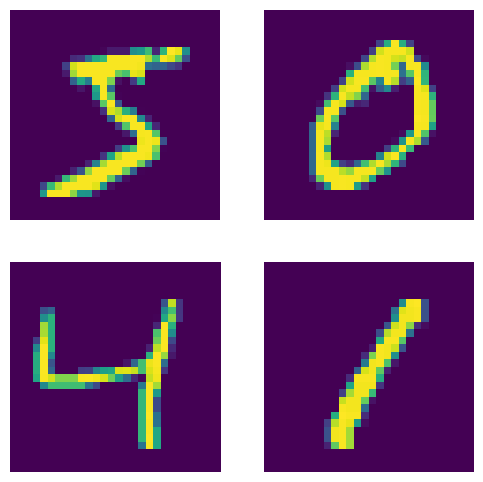

In [4]:
# 元の画像を高解像度で表示するために show_images() というヘルパー関数を利用する
from genaibook.core import show_images

show_images(mnist["train"]["image"][:4])

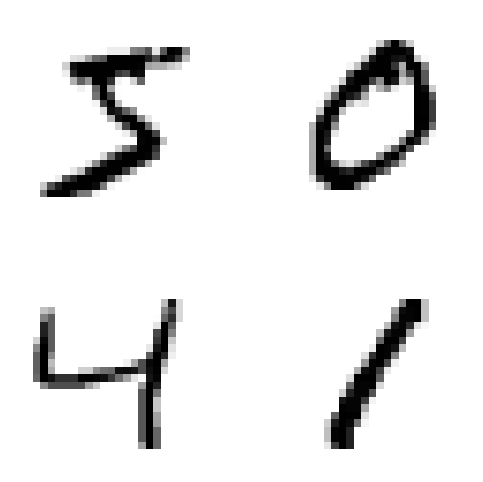

In [5]:
# 反転グレーを適用し白地に黒い数字を表示する

import matplotlib as mpl

mpl.rcParams["image.cmap"] = "gray_r"
show_images(mnist["train"]["image"][:4])

In [6]:
# 画像データを PyTorch のテンソルに変換し、訓練用データセットをシャッフルする

from torchvision import transforms

def mnist_to_tensor(samples):
  # transforms は画像の変換・拡張・操作を行う一般的なルーチンを集めたもの
  t = transforms.ToTensor()
  samples["image"] = [t(image) for image in samples["image"]]
  return samples

In [7]:
# 0 ~ 255 の範囲をとる入力ピクセルを 0 ~ 1 の範囲をとる PyTorch のテンソルに変換する
mnist = mnist.with_transform(mnist_to_tensor)
mnist["train"] = mnist["train"].shuffle(seed=1337)

In [8]:
# データセットから一枚の画像を取り出し、入力範囲を確認してみる
x = mnist["train"]["image"][0]
x.min(), x.max()

(tensor(0.), tensor(1.))

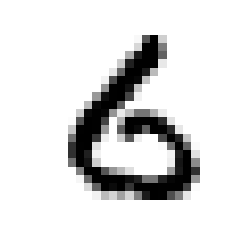

In [9]:
show_images(mnist["train"]["image"][0])

以下のコードで PyTorch の DataLoader を作成し、訓練データーの準備をする。
データセットの image 列のみ使用し、ラベルは無視する（自己教師あり学習を行うため。ラベルは後で使うけど。）

DataLoader は入力データをまとめてバッチ化する抽象化された仕組み。個々のサンプルを同じ形状の訓練バッチにまとめる役割を持つ。

In [10]:
from torch.utils.data import DataLoader

bs = 64
train_dataloader = DataLoader(mnist["train"]["image"], batch_size=bs)

3.1.2 エンコーダーのモデリング

まず、オートエンコーダーのエンコーダー部分のモデルを定義する。
画像データを扱うため画像特徴抽出に優れたものを利用する。
今回は puthae という畳み込みオートエンコーダーを使うことにする。

In [12]:
# 複数の畳み込み層を積み重ねるため、簡単なヘルパー関数 conv_block() を作成して層を作成する。

from torch import nn

def conv_block(in_channels, out_channels, kernel_size=4, stride=2, padding=1):
  return nn.Sequential(
      nn.Conv2d(
          in_channels,
          out_channels,
          kernel_size=kernel_size,
          stride=stride,
          padding=padding
      ),
      nn.BatchNorm2d(out_channels),
      nn.ReLU()
  )

In [16]:
class Encoder(nn.Module):
  def __init__(self, in_channels):
    super().__init__()
    self.conv1 = conv_block(in_channels, 128)
    self.conv2 = conv_block(128, 256)
    self.conv3 = conv_block(256, 512)
    self.conv4 = conv_block(512, 1024)
    self.linear = nn.Linear(1024, 16)

  def forward(self, x):
    x = self.conv1(x) # (batch size, 128, 14, 14)
    x = self.conv2(x) # (bs, 256, 7, 7)
    x = self.conv3(x) # (bs, 512, 3, 3)
    x = self.conv4(x) # (bs, 1024, 1, 1)
    # バッチの次元数を保持したまま平坦化する
    x = self.linear(x.flatten(start_dim=1)) # (bs, 16)
    return x

入力画像を実際にエンコーダーに渡せるか確認してみる。

In [17]:
mnist["train"]["image"][0].shape

torch.Size([1, 28, 28])

一枚の画像をバッチ化し、新たな次元を Pytorch の None インデックスとして追加する。

In [18]:
in_channels = 1

x = mnist["train"]["image"][0][None, :]
encoder = Encoder(in_channels).eval()

encoded = encoder(x)
encoded.shape

torch.Size([1, 16])

これで28*28の画像をわずか16個の数値からなるベクトルに変換できた。

十分に訓練できればエンコーダーによって計算される表現は元のピクセル余地もはるかに少ない次元のデータになる。
もちろんこの段階ではまだ訓練されていないため、この表現はまだ無意味である。⭐️どういうこっちゃ。

In [19]:
encoded

tensor([[ 0.0145,  0.0096,  0.0186, -0.0108, -0.0210, -0.0193,  0.0135, -0.0038,
          0.0119, -0.0075, -0.0012, -0.0097,  0.0279,  0.0106, -0.0201, -0.0275]],
       grad_fn=<AddmmBackward0>)

続いて、６４枚の画像からなるバッチにも対応できることを確認してみよう。

In [20]:
batch = next(iter(train_dataloader))
encoded = Encoder(in_channels=1)(batch)
batch.shape, encoded.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64, 16]))

これで画像を中間表現に変換する Encoder モデルが完成した。

次はデコーダーの実装に移る。